# Netflix Dataset - Exploratory Data Analysis
The dataset is analyzed to explore content distribution, release years, ratings, countries and duration.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")

## Loading the Dataset

In [3]:
df = pd.read_csv("netflix_data.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (8807, 12)


In [6]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [7]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
print("Dataset Size:", df.size)

Dataset Size: 105684


In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [14]:
df = df.drop(columns=["show_id", "description"], errors="ignore")

print(df.columns)

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')


In [15]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [16]:
df.isnull().sum()

type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
dtype: int64

In [17]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [18]:
df["year_added"] = df["date_added"].dt.year

In [19]:
df["month_added"] = df["date_added"].dt.month

In [20]:
df["movie_duration_min"] = np.where(
    df["type"] == "Movie",
    df["duration"],
    np.nan
)

df["tv_show_seasons"] = np.where(
    df["type"] == "TV Show",
    df["duration"],
    np.nan
)

In [21]:
df[["type","duration","movie_duration_min","tv_show_seasons"]].head(10)

,type,duration,movie_duration_min,tv_show_seasons
0,Movie,90 min,90 min,NaN
1,TV Show,2 Seasons,NaN,2 Seasons
2,TV Show,1 Season,NaN,1 Season
3,TV Show,1 Season,NaN,1 Season
4,TV Show,2 Seasons,NaN,2 Seasons
5,TV Show,1 Season,NaN,1 Season
6,Movie,91 min,91 min,NaN
7,Movie,125 min,125 min,NaN
8,TV Show,9 Seasons,NaN,9 Seasons
9,Movie,104 min,104 min,NaN


In [22]:
df.to_csv("Clean_Netflix_Data.csv", index=False)

print("Clean Dataset Saved Successfully!")

Clean Dataset Saved Successfully!


## Converting Duration columns to Numeric
The movie_duration_min and tv_show_seasons columns contain text like "90 min" and "2 Seasons". We are extract just the numbers.

In [23]:
df["movie_duration_min"] = df["movie_duration_min"].str.extract(r"(\d+)")

df["movie_duration_min"] = pd.to_numeric(df["movie_duration_min"])


In [24]:
df["tv_show_seasons"] = df["tv_show_seasons"].str.extract(r"(\d+)")

df["tv_show_seasons"] = pd.to_numeric(df["tv_show_seasons"])

# Univariate Analysis

## Distribution of Release Year
Most Netflix content belongs to more recent release years.

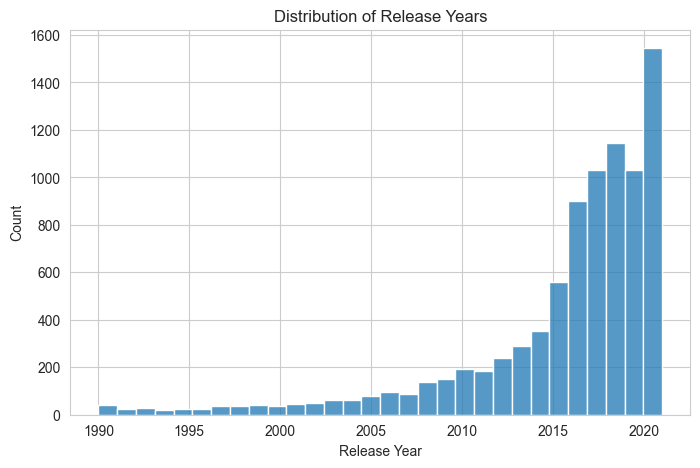

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(data=df[df["release_year"] >= 1990], x="release_year", bins=30)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()


## Distribution of Movie Duration
Checking how long most movies on Netflix are.

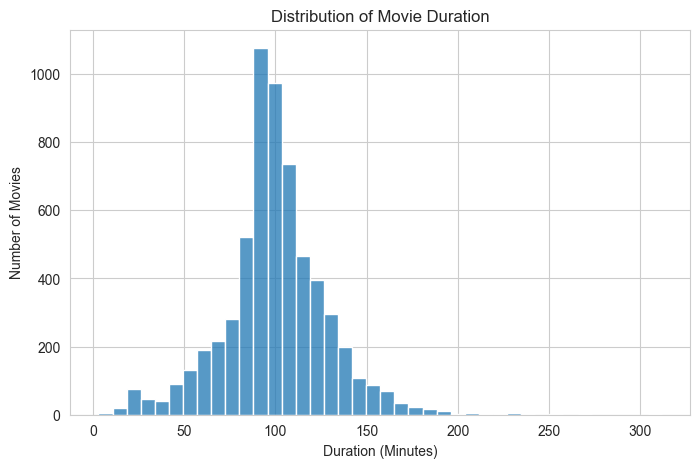

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["movie_duration_min"].dropna(), bins=40)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

## Distribution of TV Show Seasons
Most TV shows have very few seasons.

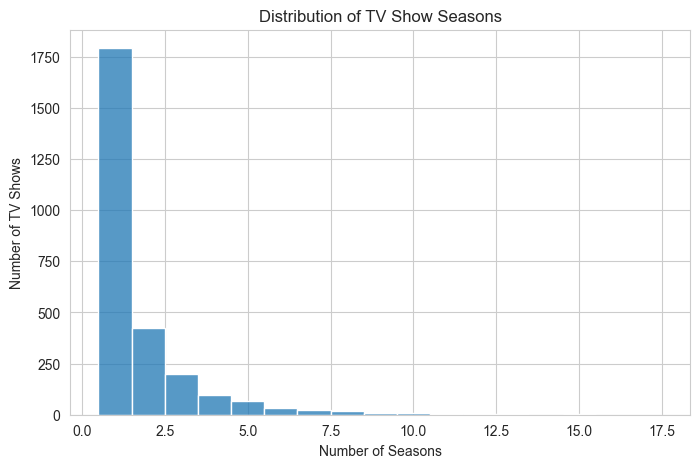

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["tv_show_seasons"].dropna(), discrete=True)

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.show()

## Boxplot - Movie Duration
Helps us spot outliers — very short or very long movies.

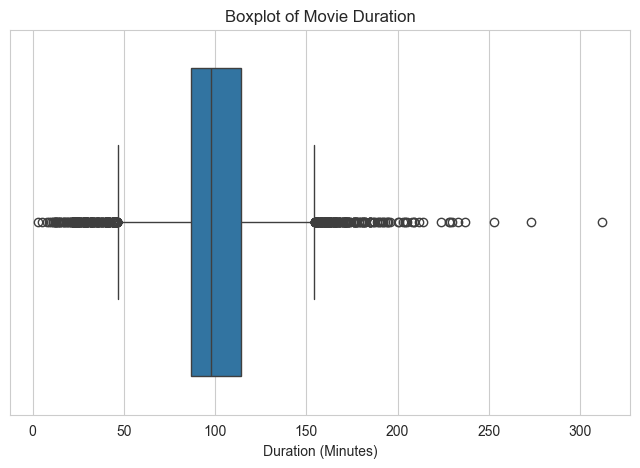

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["movie_duration_min"])

plt.title("Boxplot of Movie Duration")
plt.xlabel("Duration (Minutes)")

plt.show()

## Boxplot - TV Show Seasons
Shows the spread and any outlier shows with many seasons.

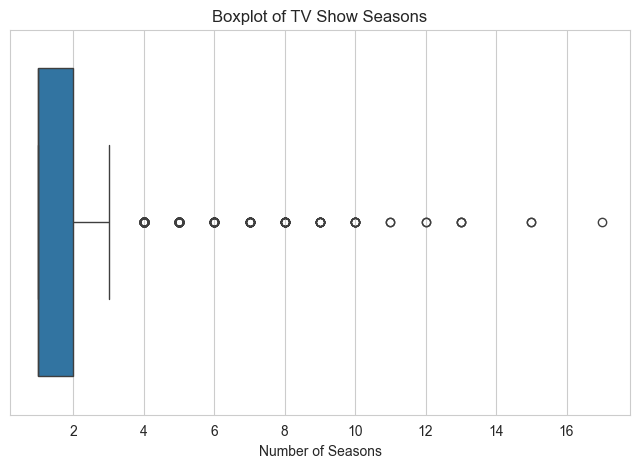

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["tv_show_seasons"])

plt.title("Boxplot of TV Show Seasons")
plt.xlabel("Number of Seasons")

plt.show()

## Content Type Distribution
Comparing how many Movies vs TV Shows are on Netflix.

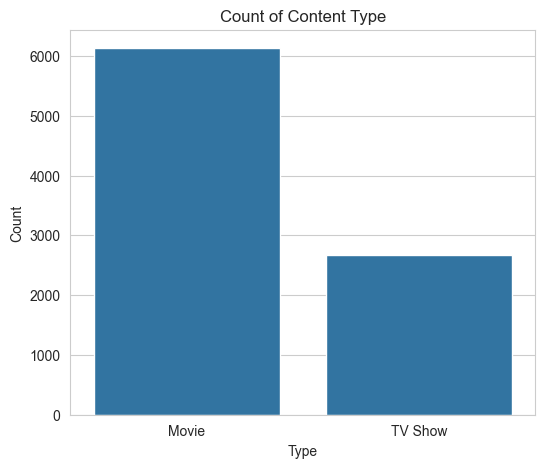

In [30]:
plt.figure(figsize=(6,5))

sns.countplot(x=df["type"])

plt.title("Count of Content Type")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

## Content Rating Distribution
Shows which age ratings are most common on Netflix.

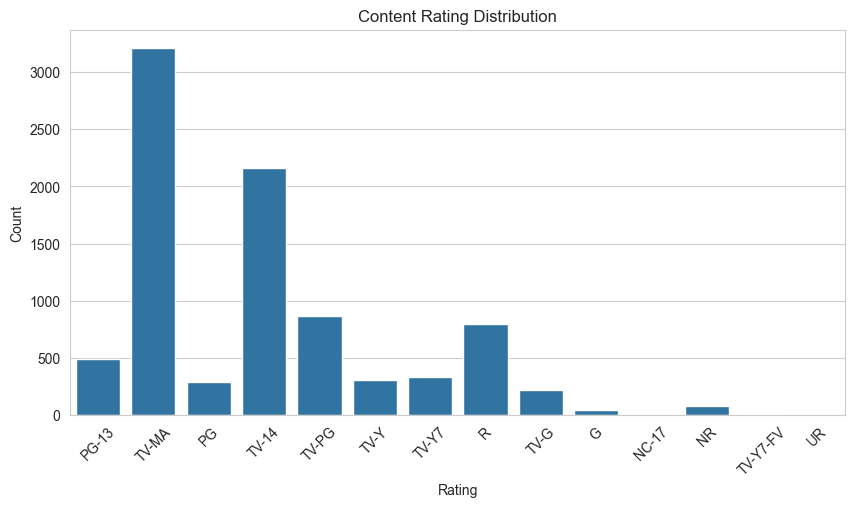

In [31]:
df = df[~df["rating"].str.contains("min", na=False)]
plt.figure(figsize=(10,5))

sns.countplot(x=df["rating"])

plt.title("Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Top 10 Countries by Titles
Countries that produce the most Netflix content.

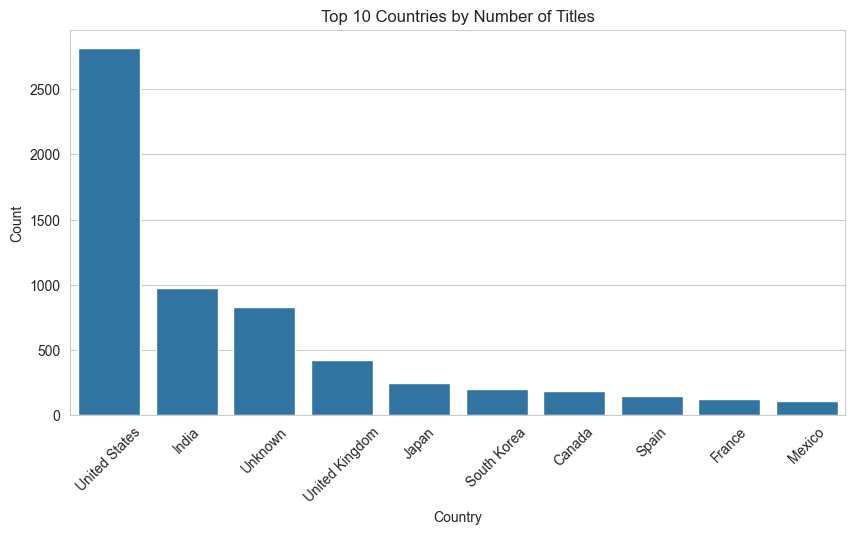

In [32]:
top=df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top.index, y=top.values)

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Country")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

<br><br><br><br><br><br><br>

# Bivariate & Multivariate Analysis

This section explores relationships between multiple variables using comparative and correlation-based visualizations.


<br><br>

## Scatter Plot - Release Year vs Movie Duration

This plot shows the relationship between movie release year and duration.

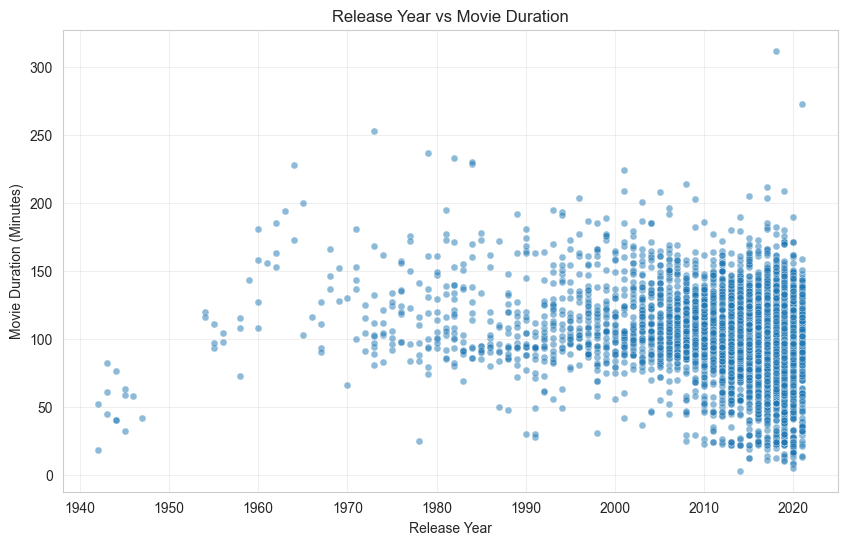

In [33]:
plt.figure(figsize=(10,6))

movie_df = df[df["type"] == "Movie"]

sns.scatterplot(
    data=movie_df,
    x="release_year",
    y="movie_duration_min",
    alpha=0.5,
    s=25
)

plt.title("Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Movie Duration (Minutes)")
plt.grid(True, alpha=0.3)

plt.show()

### Key Insight

Most Netflix movies released after 2000 have durations between 80–140 minutes, with no strong relationship between release year and duration.

<br><br><br><br>

## Boxplot - Content Type vs Movie Duration
This boxplot compares the distribution of movie duration across different content types.

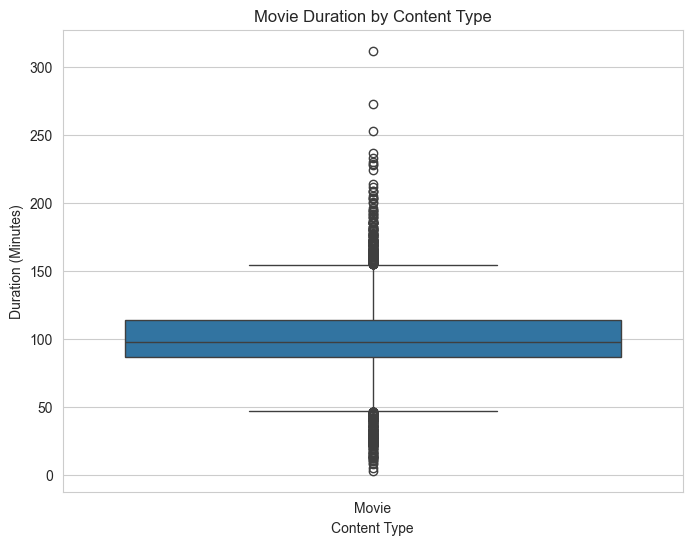

In [34]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df[df["type"]=="Movie"],
    x="type",
    y="movie_duration_min"
)

plt.title("Movie Duration by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Duration (Minutes)")

plt.show()

### Key Insight
Most movies have durations around 90–110 minutes, with a few outliers having unusually short or long durations.

<br><br><br><br>


## Crosstab - Content Type vs Rating
This heatmap shows the relationship between content type and content rating.

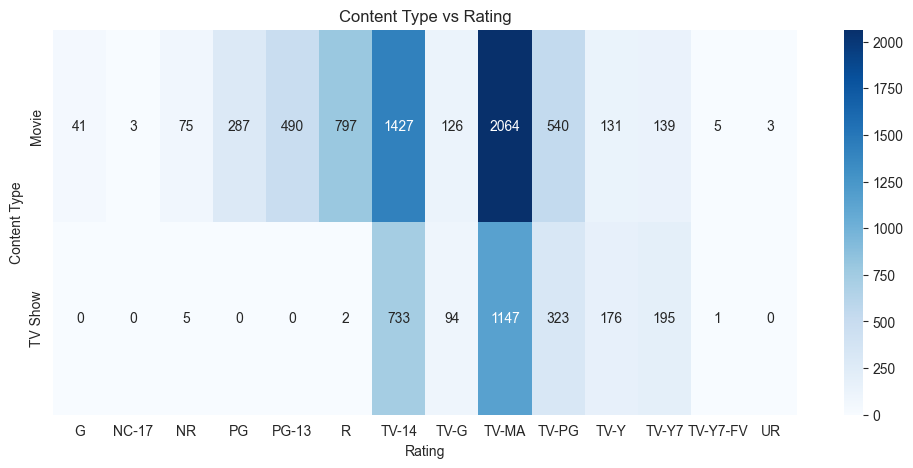

In [35]:
# Create Crosstab
crosstab = pd.crosstab(df["type"], df["rating"])

# Plot Heatmap
plt.figure(figsize=(12,5))

sns.heatmap(
    crosstab,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Content Type vs Rating")
plt.xlabel("Rating")
plt.ylabel("Content Type")

plt.show()

### Key Insight
TV-MA is the most common rating for both Movies and TV Shows.

<br><br><br><br>

## Correlation Heatmap
This heatmap shows the correlation between numerical variables in the dataset.

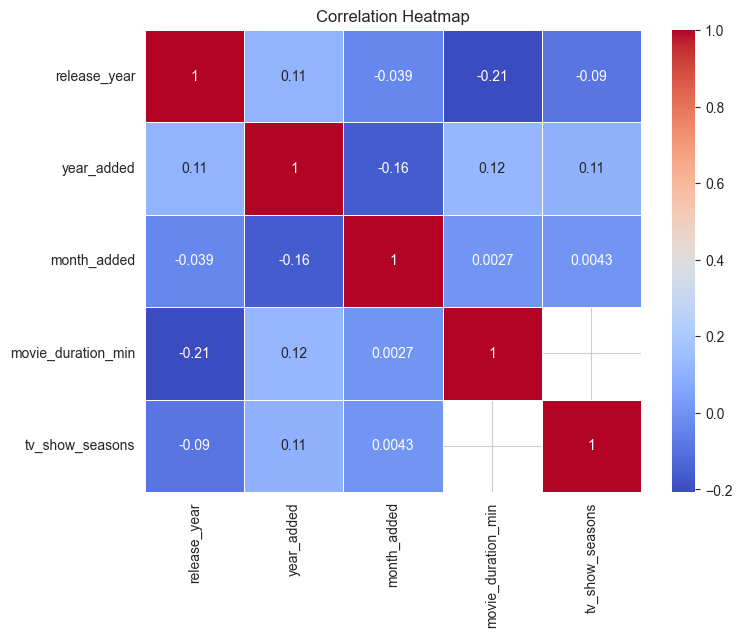

In [36]:
# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Plot Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Key Insight
Most numerical variables have weak correlations, indicating no strong linear relationship.

<br><br><br><br>

## Pairplot of Numerical Variables
This pairplot shows pairwise relationships between the numerical variables in the dataset.

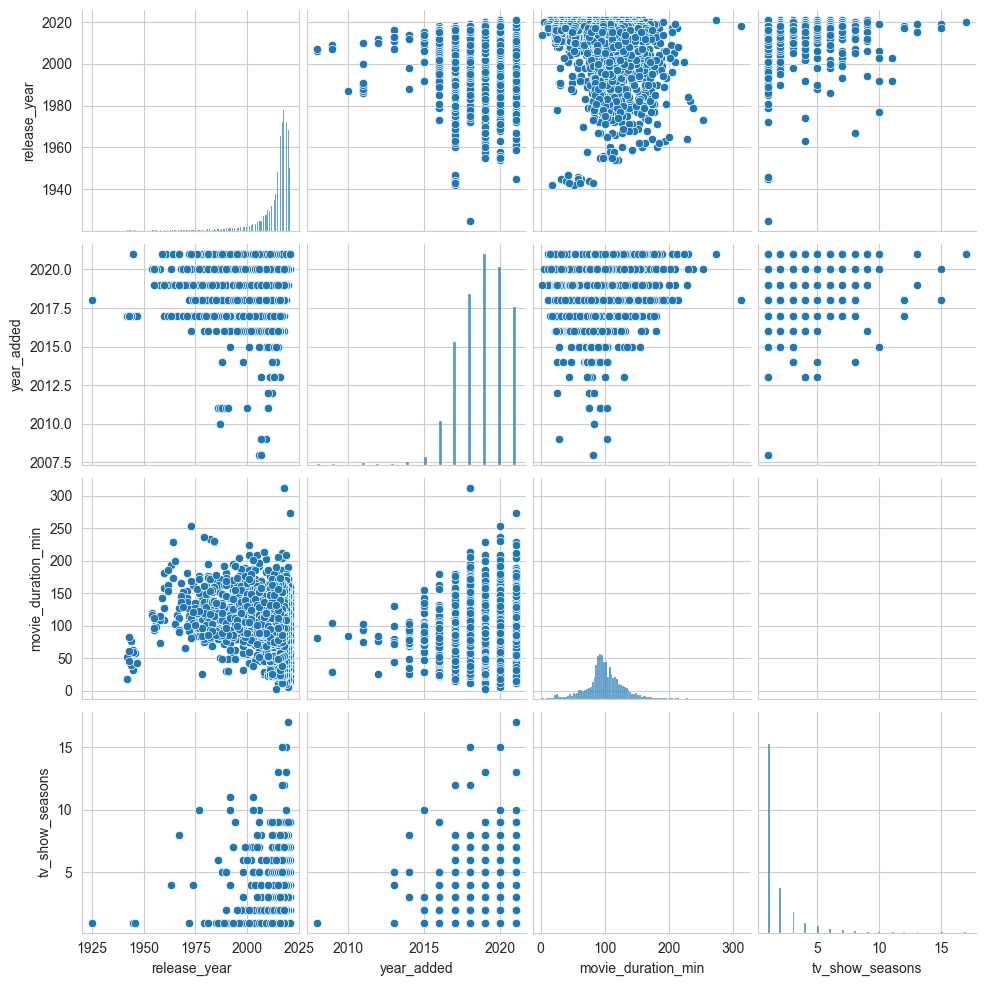

In [37]:
# Select only numerical columns
pairplot_df = df[[
    "release_year",
    "year_added",
    "movie_duration_min",
    "tv_show_seasons"
]]

# Pairplot
sns.pairplot(pairplot_df)

plt.show()

### Key Insight

Most numerical variables show weak relationships, with no clear linear patterns.

<br><br><br><br>

## Violin Plot - Movie Duration
This violin plot shows the distribution and density of movie durations.

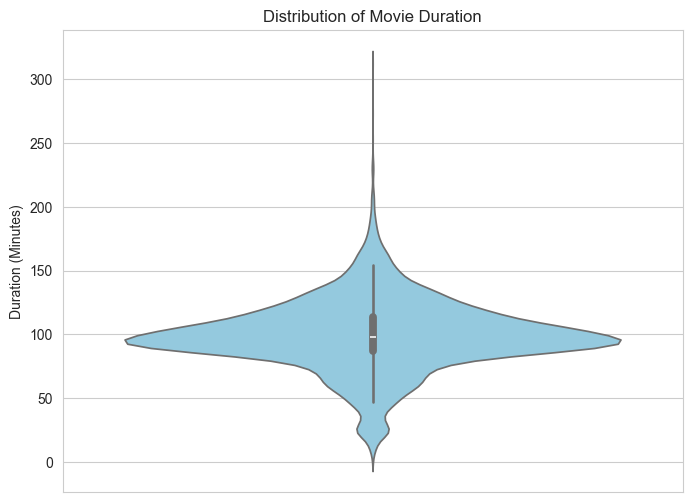

In [38]:
plt.figure(figsize=(8,6))

sns.violinplot(
    y=df["movie_duration_min"],
    color="skyblue"
)

plt.title("Distribution of Movie Duration")
plt.ylabel("Duration (Minutes)")

plt.show()

### Key Insight
Most movies are concentrated around 90–110 minutes, with a few long-duration outliers.

# 

# 

# Business KPI

Total Tiles

In [39]:
print("Total Titles:", df.shape[0])        

Total Titles: 8804


Total Movies

In [40]:
print("Total Movies:", (df['type'] == 'Movie').sum())

Total Movies: 6128


Total TV Shows

In [41]:
print("Total TV Shows:", (df['type'] == 'TV Show').sum())

Total TV Shows: 2676


Top Country

In [42]:
df['country'].value_counts().head(2)

country
United States    2815
India             972
Name: count, dtype: int64

Common Rating

In [43]:
df['rating'].mode()[0]

'TV-MA'

# 

# Movies vs TV Shows

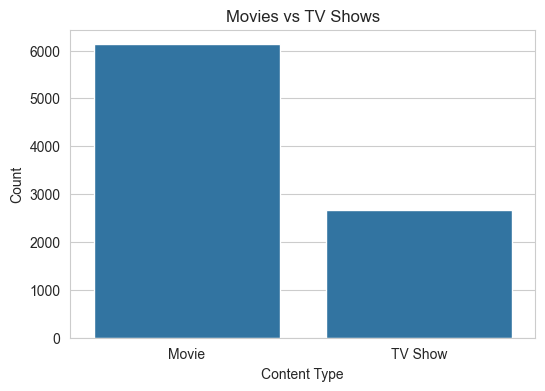

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

### Key Insight
Movies make up the majority of Netflix's content library.

# 

# Top Genre

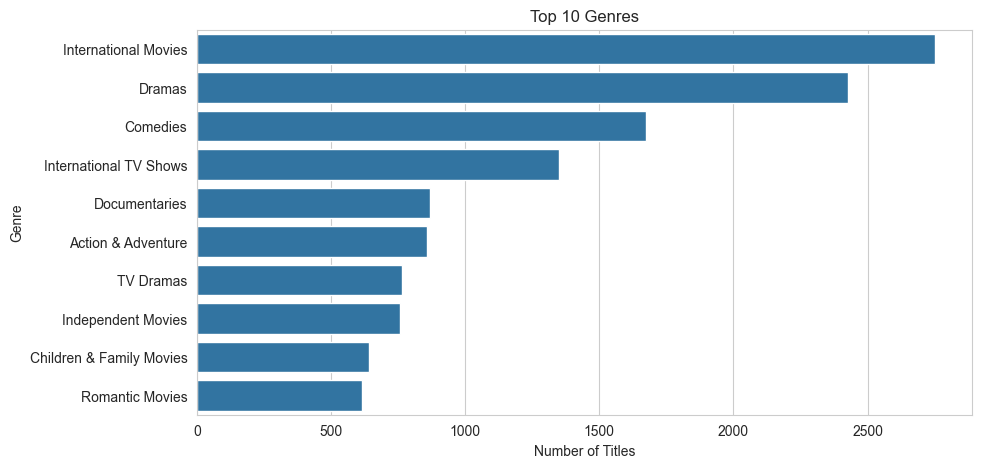

In [45]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

### Key Insight
Drama, International Movies, and Comedies are among the most popular genres.

# 

# Content Growth by Year

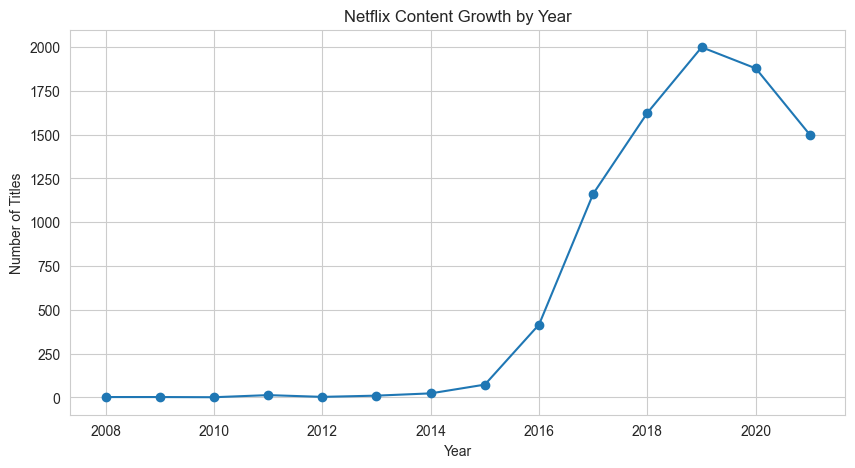

In [46]:
year_data = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(year_data.index, year_data.values, marker='o')

plt.title("Netflix Content Growth by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

### Key Insight
Netflix experienced rapid content growth after 2015.

# 

# Top Countries

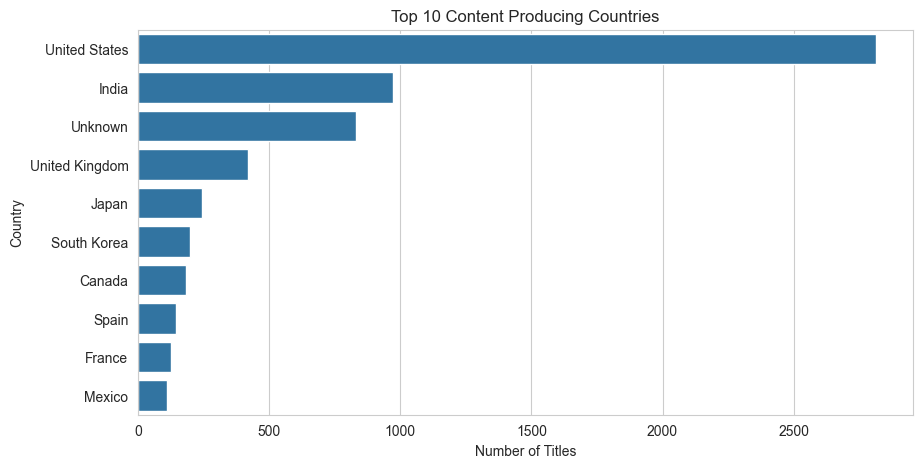

In [47]:
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_country.values, y=top_country.index)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

### Key Insight
The United States contributes the largest share of Netflix content, followed by India and the United Kingdom.

# 

# Business Insights

### Global Expansion
The United States is the largest content producer.

### Content Trends
Content additions increased rapidly between 2016 and 2020.

### Audience Preference
Drama, International Movies, and Comedy are the most common genres.

### Duration Pattern
Most movies have a duration between 80 and 120 minutes.